## Setup and Imports

In [2]:
# Install required packages
!pip install -q google-generativeai captum

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')
import random
from datetime import datetime

# Gemini API
import google.generativeai as genai

# Deep learning
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from captum.attr import LayerIntegratedGradients

# NLP
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# PROJECT_PATH = '/content/drive/MyDrive/Precog_NLP_Task_FIXED'
# RESULTS_PATH = f'{PROJECT_PATH}/outputs/task4'

# # Create results directory
# import os
# os.makedirs(RESULTS_PATH, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✓ All libraries imported")
print(f"✓ Using device: {device}")
# print(f"✓ Results will be saved to: {RESULTS_PATH}")

✓ All libraries imported
✓ Using device: cuda


## Configure Gemini API

In [3]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GEMINI_API_KEY)

# Initialize model
gemini_model = genai.GenerativeModel('gemma-3-27b-it')

genai.configure(api_key=GEMINI_API_KEY)

# Test connection
try:
    test_response = gemini_model.generate_content("Say 'API working'")
    print("✓ Gemini API configured successfully")
    print(f"  Test response: {test_response.text}")
except Exception as e:
    print(f"✗ API test failed: {e}")

# Generation parameters
generation_config = {
    'temperature': 1.4,
    'top_p': 0.95,
    'top_k': 40,
    'max_output_tokens': 300,
}

def generate_with_gemini(prompt, temperature=1.0, max_retries=3):
    """
    Generate text using Gemini API with retry logic.
    """
    config = generation_config.copy()
    config['temperature'] = temperature

    for attempt in range(max_retries):
        try:
            response = gemini_model.generate_content(
                prompt,
                generation_config=config
            )
            return response.text.strip()
        except Exception as e:
            if attempt < max_retries - 1:
                wait_time = (attempt + 1) * 2
                print(f"  ⚠ API error, retrying in {wait_time}s...")
                time.sleep(wait_time)
            else:
                print(f"  ✗ Generation failed after {max_retries} attempts: {e}")
                return ""

print("\n✓ Gemini generation function ready")

✓ Gemini API configured successfully
  Test response: API working! 🚀 

Is there anything I can help you with? Let me know what you'd like me to do with this API access.


✓ Gemini generation function ready


## Load Detector Model (Tier C)

In [24]:
print("Loading Tier C detector model...\n")

MODEL_PATH = f'tierC_transformer_tertiary'

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, num_labels=3)
    print(f"✓ Loaded fine-tuned model from {MODEL_PATH}")
except:
    print("  Using base DistilBERT (fine-tuned model not found)")
    tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
    model = AutoModelForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=3
    )

model.eval()
model = model.to(device)

# Label mapping
label_to_id = {'human': 0, 'ai_neutral': 1, 'ai_mimicked': 2}
id_to_label = {v: k for k, v in label_to_id.items()}

def predict_with_confidence(text):
    """
    Predict class and confidence for text.
    Returns: (predicted_label, confidence, all_probs)
    """
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[0]
        pred_id = torch.argmax(probs).item()

    pred_label = id_to_label[pred_id]
    confidence = probs[pred_id].item()
    all_probs = {id_to_label[i]: probs[i].item() for i in range(3)}

    return pred_label, confidence, all_probs

print("\n✓ Detector model loaded and ready")

Loading Tier C detector model...



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights: 0it [00:00, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: tierC_transformer_tertiary
Key                                                                                                    | Status     | 
-------------------------------------------------------------------------------------------------------+------------+-
base_model.model.distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_B.default.weight | UNEXPECTED | 
base_model.model.distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_A.default.weight | UNEXPECTED | 
base_model.model.classifier.weight                                                                     | UNEXPECTED | 
base_model.model.pre_classifier.bias                                                                   | UNEXPECTED | 
base_model.model.pre_classifier.weight                                                                 | UNEXPECTED | 
base_model.model.classifier.bias                                                      

✓ Loaded fine-tuned model from tierC_transformer_tertiary

✓ Detector model loaded and ready


---
#  Mutation Library

26 diverse strategies covering all aspects of Victorian style

In [25]:
# === MUTATION LIBRARY (26 Diverse Strategies) ===

MUTATION_LIBRARY = [
    # === PUNCTUATION MUTATIONS (Victorian markers) ===
    "Add 2-3 semicolons to join related clauses instead of using periods. Maintain the exact same meaning.",

    "Replace some commas with em-dashes (—) for parenthetical remarks. Keep the content identical.",

    "Remove most semicolons and split into shorter, punchier sentences of 8-12 words each.",

    "Add 1-2 colons to introduce lists or explanations in a more formal Victorian style.",

    # === VOCABULARY MUTATIONS ===
    "Replace 3-5 modern words with Victorian-era synonyms (e.g., 'very' → 'exceedingly', 'said' → 'observed', 'connection' → 'connexion'). Keep meaning identical.",

    "Use more archaic constructions: 'one might observe' instead of 'you can see', 'it behoves us' instead of 'we should'.",

    "Simplify vocabulary - use common, direct Anglo-Saxon words instead of Latin-derived formal terms.",

    "Add more formal, elevated diction throughout (e.g., 'regarding' → 'concerning', 'about' → 'pertaining to').",

    "Introduce exactly 2 Victorian-era terms naturally: choose from [connexion, propriety, countenance, disposition, establishment, civility, rank, station].",

    # === SENTENCE STRUCTURE MUTATIONS ===
    "Rewrite with longer, more complex sentences averaging 20-25 words each, using multiple clauses.",

    "Break into shorter, punchier sentences averaging 8-12 words. Remove all subordinate clauses.",

    "Vary sentence length dramatically - alternate between very short (5 words) and very long (30+ words) sentences.",

    "Create parallel sentence structures for rhythmic emphasis (e.g., 'It was A, it was B, it was C').",

    # === STYLE MUTATIONS ===
    "Add subtle irony through careful word choice and Victorian understatement. Make the tone more wry.",

    "Make the tone more formal, detached, and observational - like a Victorian scholar documenting phenomena.",

    "Make the language more direct, conversational, and immediate. Remove passive constructions.",

    "Add more sensory details and vivid, concrete descriptions in Victorian style.",

    # === TRANSITION MUTATIONS ===
    "Remove obvious transitions like 'Furthermore', 'Moreover', 'Additionally' - jump between ideas more naturally.",

    "Add explicit logical transition phrases to make connections crystal clear (However, Nevertheless, Consequently).",

    "Use more subtle, elegant Victorian connectives: 'Withal', 'Notwithstanding', 'Whence', 'Thereby'.",

    # === VOICE MUTATIONS ===
    "Shift to more passive voice constructions for a formal, detached Victorian tone.",

    "Convert to active voice throughout for directness and energy. Remove all passive constructions.",

    "Mix active and passive voice naturally based on emphasis - passive for formality, active for clarity.",

    # === GRAMMAR MUTATIONS ===
    "Introduce 1-2 subtle Victorian grammatical patterns: inverted word order ('Arrived the lady'), subjunctive mood ('were it not'), or split infinitives.",

    "Perfect the grammar - remove all informal or colloquial constructions completely. Make it impeccable.",

    # === RHYTHM MUTATIONS ===
    "Make sentence rhythm more varied, unpredictable, and syncopated - avoid any regular pattern.",

    "Create regular, predictable sentence rhythm with balanced clauses and parallel structures."
]

print(f"✓ Loaded {len(MUTATION_LIBRARY)} mutation strategies")
print(f"\nCategories:")
print(f"  • Punctuation: 4 strategies")
print(f"  • Vocabulary: 5 strategies")
print(f"  • Sentence Structure: 4 strategies")
print(f"  • Style: 4 strategies")
print(f"  • Transitions: 3 strategies")
print(f"  • Voice: 3 strategies")
print(f"  • Grammar: 2 strategies")
print(f"  • Rhythm: 2 strategies")

✓ Loaded 27 mutation strategies

Categories:
  • Punctuation: 4 strategies
  • Vocabulary: 5 strategies
  • Sentence Structure: 4 strategies
  • Style: 4 strategies
  • Transitions: 3 strategies
  • Voice: 3 strategies
  • Grammar: 2 strategies
  • Rhythm: 2 strategies


## Enhanced Mutation Function

In [26]:
def mutate_text(text, mutation_strength="medium", verbose=False):
    """
    Apply random mutation from library with strength control.

    Args:
        text: Text to mutate
        mutation_strength: "weak", "medium", or "strong"
        verbose: Print mutation strategy used

    Returns:
        Mutated text (or original if mutation fails)
    """
    # Select random mutation strategy
    mutation_strategy = random.choice(MUTATION_LIBRARY)

    if verbose:
        print(f"  Applying: {mutation_strategy[:60]}...")

    # Temperature map by strength
    temp_map = {
        "weak": 0.9,      # Subtle changes
        "medium": 1.1,    # Moderate changes
        "strong": 1.3     # Aggressive rewrite
    }
    temperature = temp_map.get(mutation_strength, 1.1)

    # Construct mutation prompt
    mutation_prompt = f"""{mutation_strategy}

Original text:
{text}

Rewritten text (apply the change but keep the core meaning identical):"""

    # Generate mutation
    try:
        mutated = generate_with_gemini(mutation_prompt, temperature=temperature)

        # Validation: ensure mutation produced reasonable output
        words = mutated.split()
        if len(words) < 50 or len(words) > 300:
            if verbose:
                print(f"  ⚠ Mutation failed validation (length: {len(words)} words), using original")
            return text

        return mutated

    except Exception as e:
        if verbose:
            print(f"  ⚠ Mutation error: {e}, using original")
        return text

print("✓ Enhanced mutation function ready")

✓ Enhanced mutation function ready


## Sentence-Level Crossover

In [27]:
def crossover_sentences(parent1, parent2, verbose=False):
    """
    Sentence-level crossover with LLM smoothing.

    Combines sentences from two high-fitness parents to create offspring.
    """
    # Split into sentences
    sents1 = sent_tokenize(parent1)
    sents2 = sent_tokenize(parent2)

    if len(sents1) < 2 or len(sents2) < 2:
        if verbose:
            print("  ⚠ Not enough sentences for crossover, returning parent1")
        return parent1

    # Randomly select sentences from each parent
    offspring_sents = []
    max_sents = min(len(sents1), len(sents2))

    for i in range(max_sents):
        if random.random() < 0.5:
            offspring_sents.append(sents1[i])
        else:
            offspring_sents.append(sents2[i])

    # Add remaining sentences from longer parent
    if len(sents1) > max_sents:
        offspring_sents.extend(sents1[max_sents:])
    elif len(sents2) > max_sents:
        offspring_sents.extend(sents2[max_sents:])

    # Combine sentences
    offspring = ' '.join(offspring_sents)

    if verbose:
        print(f"  Combined {len(offspring_sents)} sentences from parents")

    # LLM smoothing to fix awkward transitions
    smooth_prompt = f"""The following paragraph was created by combining sentences from two different texts.
Smooth the transitions between sentences WITHOUT changing the content or meaning.
Just fix any awkward connections and add minimal transition words if absolutely needed.

Paragraph:
{offspring}

Smoothed version (keep it natural):"""

    try:
        smoothed = generate_with_gemini(smooth_prompt, temperature=0.8)

        # Validation
        if smoothed and len(smoothed.split()) >= 50:
            return smoothed
        else:
            if verbose:
                print("  ⚠ Smoothing failed, returning unsmoothed offspring")
            return offspring

    except Exception as e:
        if verbose:
            print(f"  ⚠ Smoothing error: {e}, returning unsmoothed offspring")
        return offspring

print("✓ Crossover function ready")

✓ Crossover function ready


## Adaptive Mutation Controller

In [28]:
class AdaptiveMutationController:
    """
    Dynamically adjusts mutation strength based on evolution progress.
    Increases mutation strength when evolution stagnates.
    """

    def __init__(self, patience=2, min_improvement=0.01):
        self.patience = patience
        self.min_improvement = min_improvement
        self.stagnation_counter = 0
        self.prev_best_fitness = 0.0
        self.current_strength = "medium"

    def update(self, best_fitness):
        """
        Update mutation strength based on fitness improvement.

        Returns:
            Current mutation strength
        """
        improvement = best_fitness - self.prev_best_fitness

        if improvement < self.min_improvement:
            self.stagnation_counter += 1
        else:
            self.stagnation_counter = 0

        # Adjust strength based on stagnation
        if self.stagnation_counter >= self.patience:
            if self.current_strength == "weak":
                self.current_strength = "medium"
            elif self.current_strength == "medium":
                self.current_strength = "strong"
            # Reset counter after adjustment
            self.stagnation_counter = 0
        elif improvement > self.min_improvement * 3:
            # Large improvement - can reduce strength
            if self.current_strength == "strong":
                self.current_strength = "medium"
            elif self.current_strength == "medium":
                self.current_strength = "weak"

        self.prev_best_fitness = best_fitness
        return self.current_strength

    def get_strength(self):
        return self.current_strength

print("✓ Adaptive mutation controller ready")

✓ Adaptive mutation controller ready


## Duplicate Detection System

In [29]:
class DuplicateDetector:
    """
    Detects near-duplicate texts using n-gram similarity.
    Ensures population diversity.
    """

    def __init__(self, similarity_threshold=0.85, n=3):
        self.similarity_threshold = similarity_threshold
        self.n = n
        self.seen_texts = []
        self.duplicate_count = 0

    def _get_ngrams(self, text):
        """Extract word n-grams from text."""
        words = text.lower().split()
        return set(tuple(words[i:i+self.n]) for i in range(len(words)-self.n+1))

    def _jaccard_similarity(self, ngrams1, ngrams2):
        """Calculate Jaccard similarity between two n-gram sets."""
        if not ngrams1 or not ngrams2:
            return 0.0
        intersection = len(ngrams1 & ngrams2)
        union = len(ngrams1 | ngrams2)
        return intersection / union if union > 0 else 0.0

    def is_duplicate(self, text):
        """
        Check if text is too similar to any previously seen text.

        Returns:
            True if duplicate, False otherwise
        """
        text_ngrams = self._get_ngrams(text)

        for seen_text in self.seen_texts:
            seen_ngrams = self._get_ngrams(seen_text)
            similarity = self._jaccard_similarity(text_ngrams, seen_ngrams)

            if similarity >= self.similarity_threshold:
                self.duplicate_count += 1
                return True

        # Not a duplicate - add to seen
        self.seen_texts.append(text)
        return False

    def get_stats(self):
        return {
            'unique_texts': len(self.seen_texts),
            'duplicates_rejected': self.duplicate_count
        }

print("✓ Duplicate detector ready")

✓ Duplicate detector ready


## Step 1: Generate Initial Population

In [30]:
print("="*80)
print("STEP 1: GENERATING INITIAL POPULATION")
print("="*80)

# Topic for generation
TOPIC = "the nature of social class and its impact on individual relationships in Victorian society"

print(f"\nTopic: {TOPIC}")
print(f"\nGenerating 10 diverse AI paragraphs using Gemini...\n")

# Use varied prompts for diversity
prompt_templates = [
    # Style 1: Encyclopedic
    """Write a factual, encyclopedic 100-200 word paragraph about: {topic}.
Use neutral, modern language. Be clear and informative.""",

    # Style 2: Academic
    """Write an academic 100-200 word paragraph discussing: {topic}.
Use scholarly but accessible language.""",

    # Style 3: Narrative
    """Write a narrative 100-200 word paragraph explaining: {topic}.
Use engaging, clear prose.""",

    # Style 4: Analytical
    """Write an analytical 100-200 word paragraph examining: {topic}.
Focus on key patterns and implications.""",

    # Style 5: Descriptive
    """Write a descriptive 100-200 word paragraph about: {topic}.
Paint a clear picture with specific details."""
]

population = []
initial_fitness = []

for i in range(10):
    print(f"Generating paragraph {i+1}/10...", end=' ')

    # Use varied prompts for diversity
    prompt = prompt_templates[i % len(prompt_templates)].format(topic=TOPIC)

    # Generate with higher temperature for diversity
    paragraph = generate_with_gemini(prompt, temperature=1.2)

    if not paragraph:
        print("Failed, skipping")
        continue

    # Evaluate fitness
    pred, conf, probs = predict_with_confidence(paragraph)
    fitness = probs['human']

    population.append(paragraph)
    initial_fitness.append(fitness)

    print(f"Fitness: {fitness:.3f} (pred: {pred})")
    time.sleep(1)  # Rate limiting

print("\n" + "="*80)
print("INITIAL POPULATION STATISTICS")
print("="*80)
print(f"\nPopulation size: {len(population)}")
print(f"Average fitness: {np.mean(initial_fitness):.3f}")
print(f"Max fitness: {max(initial_fitness):.3f}")
print(f"Min fitness: {min(initial_fitness):.3f}")
print(f"Std dev: {np.std(initial_fitness):.3f}")

best_idx = np.argmax(initial_fitness)
print(f"\nBest paragraph (#{best_idx+1}, fitness={initial_fitness[best_idx]:.3f}):")
print(f"{population[best_idx][:250]}...")

STEP 1: GENERATING INITIAL POPULATION

Topic: the nature of social class and its impact on individual relationships in Victorian society

Generating 10 diverse AI paragraphs using Gemini...

Generating paragraph 1/10... Fitness: 0.330 (pred: ai_mimicked)
Generating paragraph 2/10... Fitness: 0.326 (pred: ai_mimicked)
Generating paragraph 3/10... Fitness: 0.329 (pred: ai_mimicked)
Generating paragraph 4/10... Fitness: 0.330 (pred: ai_mimicked)
Generating paragraph 5/10... Fitness: 0.338 (pred: ai_mimicked)
Generating paragraph 6/10... Fitness: 0.328 (pred: ai_mimicked)
Generating paragraph 7/10... Fitness: 0.330 (pred: ai_mimicked)
Generating paragraph 8/10... Fitness: 0.329 (pred: ai_mimicked)
Generating paragraph 9/10... Fitness: 0.335 (pred: ai_mimicked)
Generating paragraph 10/10... Fitness: 0.328 (pred: ai_mimicked)

INITIAL POPULATION STATISTICS

Population size: 10
Average fitness: 0.330
Max fitness: 0.338
Min fitness: 0.326
Std dev: 0.003

Best paragraph (#5, fitness=0.338):
Vic

## Enhanced Genetic Algorithm Loop

**Key Features:**
- Adaptive mutation strength
- Crossover + mutation operations
- Duplicate detection
- Comprehensive tracking

In [31]:
def run_enhanced_ga(
    initial_population,
    initial_fitness,
    model,
    tokenizer,
    device,
    num_generations=10,
    population_size=10,
    elite_size=3,
    crossover_rate=0.3,
    target_fitness=0.90,
    verbose=True
):
    """
    Enhanced Genetic Algorithm with adaptive mutation, crossover, and diversity control.
    """
    # Initialize components
    mutation_controller = AdaptiveMutationController(patience=2, min_improvement=0.01)
    duplicate_detector = DuplicateDetector(similarity_threshold=0.85)

    # Add initial population to duplicate detector
    for ind in initial_population:
        duplicate_detector.is_duplicate(ind)

    # Fitness evaluation function
    def evaluate_text(text, model, tokenizer, device):
        pred, conf, probs = predict_with_confidence(text)
        return probs['human']

    # Evolution tracking
    evolution_data = {
        'generation': [],
        'best_fitness': [],
        'mean_fitness': [],
        'std_fitness': [],
        'mutation_strength': [],
        'operation_counts': {
            'mutation': 0,
            'crossover': 0,
            'duplicates': 0
        }
    }

    # Initialize population
    population = initial_population.copy()
    fitness_scores = initial_fitness.copy()

    # Record generation 0
    best_fitness = max(fitness_scores)
    evolution_data['generation'].append(0)
    evolution_data['best_fitness'].append(best_fitness)
    evolution_data['mean_fitness'].append(np.mean(fitness_scores))
    evolution_data['std_fitness'].append(np.std(fitness_scores))
    evolution_data['mutation_strength'].append(mutation_controller.get_strength())

    if verbose:
        print(f"\n{'='*80}")
        print(f"GENETIC ALGORITHM EVOLUTION (Target: {target_fitness:.0%})")
        print(f"{'='*80}\n")
        print(f"Generation 0: Best={best_fitness:.3f}, Mean={np.mean(fitness_scores):.3f}")

    # Main evolution loop
    for gen in range(1, num_generations + 1):
        if verbose:
            print(f"\n{'='*80}")
            print(f"GENERATION {gen}")
            print(f"{'='*80}")

        # Check convergence
        current_best = max(fitness_scores)
        if current_best >= target_fitness:
            print(f"\n🎉 CONVERGED! Reached {current_best:.1%} Human confidence")
            break

        # Update mutation strength
        mutation_strength = mutation_controller.update(current_best)

        if verbose:
            print(f"\nCurrent best: {current_best:.3f}")
            print(f"Target: {target_fitness:.3f}")
            print(f"Gap: {target_fitness - current_best:.3f}")
            print(f"Mutation strength: {mutation_strength}")

        # Selection: Keep elite
        sorted_indices = np.argsort(fitness_scores)[::-1]
        elite_indices = sorted_indices[:elite_size]
        parents = [population[i] for i in elite_indices]

        if verbose:
            print(f"\nSelected top {elite_size} parents:")
            for i, idx in enumerate(elite_indices):
                print(f"  {i+1}. Fitness: {fitness_scores[idx]:.3f}")

        # Generate new population
        next_generation = parents.copy()  # Keep elite
        evolution_data['operation_counts']['mutation'] = 0
        evolution_data['operation_counts']['crossover'] = 0
        evolution_data['operation_counts']['duplicates'] = 0

        attempts = 0
        max_attempts = 50

        while len(next_generation) < population_size and attempts < max_attempts:
            # Decide: crossover or mutation?
            if random.random() < crossover_rate and len(parents) >= 2:
                # Crossover
                parent1, parent2 = random.sample(parents, 2)
                offspring = crossover_sentences(parent1, parent2, verbose=False)
                operation = 'crossover'
                evolution_data['operation_counts']['crossover'] += 1
            else:
                # Mutation
                parent = random.choice(parents)
                offspring = mutate_text(parent, mutation_strength, verbose=False)
                operation = 'mutation'
                evolution_data['operation_counts']['mutation'] += 1

            # Check for duplicate
            if not duplicate_detector.is_duplicate(offspring):
                next_generation.append(offspring)
            else:
                evolution_data['operation_counts']['duplicates'] += 1
                # Try again with stronger mutation
                parent = random.choice(parents)
                offspring = mutate_text(parent, "strong", verbose=False)
                if not duplicate_detector.is_duplicate(offspring):
                    next_generation.append(offspring)

            attempts += 1
            time.sleep(0.5)  # Small delay for API

        population = next_generation

        if verbose:
            print(f"\nGenerated {len(next_generation)} individuals")
            print(f"  Mutations: {evolution_data['operation_counts']['mutation']}")
            print(f"  Crossovers: {evolution_data['operation_counts']['crossover']}")
            print(f"  Duplicates rejected: {evolution_data['operation_counts']['duplicates']}")

        # Evaluate new population
        print(f"\nEvaluating generation {gen}...")
        fitness_scores = [evaluate_text(ind, model, tokenizer, device) for ind in population]

        # Record statistics
        best_fitness = max(fitness_scores)
        evolution_data['generation'].append(gen)
        evolution_data['best_fitness'].append(best_fitness)
        evolution_data['mean_fitness'].append(np.mean(fitness_scores))
        evolution_data['std_fitness'].append(np.std(fitness_scores))
        evolution_data['mutation_strength'].append(mutation_strength)

        if verbose:
            print(f"\nGeneration {gen} results:")
            print(f"  Best: {best_fitness:.3f}")
            print(f"  Mean: {np.mean(fitness_scores):.3f}")
            print(f"  Improvement: {best_fitness - evolution_data['best_fitness'][gen-1]:+.3f}")

    # Final evaluation
    final_fitness = [evaluate_text(ind, model, tokenizer, device) for ind in population]
    best_idx = np.argmax(final_fitness)

    return {
        'best_individual': population[best_idx],
        'best_fitness': final_fitness[best_idx],
        'population': population,
        'fitness_scores': final_fitness,
        'evolution_data': evolution_data,
        'duplicate_stats': duplicate_detector.get_stats()
    }

print("✓ Enhanced GA ready")

✓ Enhanced GA ready


## Run the Enhanced Genetic Algorithm

In [32]:
import nltk
nltk.download('punkt_tab')

# Run enhanced GA
results = run_enhanced_ga(
    initial_population=population,
    initial_fitness=initial_fitness,
    model=model,
    tokenizer=tokenizer,
    device=device,
    num_generations=10,
    population_size=10,
    elite_size=3,
    crossover_rate=0.3,
    target_fitness=0.90,
    verbose=True
)

print(f"\n{'='*80}")
print("EVOLUTION COMPLETE")
print(f"{'='*80}")
print(f"\nFinal best fitness: {results['best_fitness']:.3f}")
print(f"Improvement: {initial_fitness[0]:.3f} → {results['best_fitness']:.3f}")
print(f"Gain: +{(results['best_fitness'] - np.mean(initial_fitness)):.3f}")
print(f"\nDuplicate statistics:")
print(f"  Unique texts: {results['duplicate_stats']['unique_texts']}")
print(f"  Duplicates rejected: {results['duplicate_stats']['duplicates_rejected']}")

print(f"\n{'='*80}")
print("BEST EVOLVED PARAGRAPH")
print(f"{'='*80}")
print(f"\n{results['best_individual']}")


GENETIC ALGORITHM EVOLUTION (Target: 90%)

Generation 0: Best=0.338, Mean=0.330

GENERATION 1

Current best: 0.338
Target: 0.900
Gap: 0.562
Mutation strength: weak

Selected top 3 parents:
  1. Fitness: 0.338
  2. Fitness: 0.335
  3. Fitness: 0.330


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
ERROR:tornado.access:503 POST /v1beta/models/gemma-3-27b-it:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2291.77ms



Generated 10 individuals
  Mutations: 6
  Crossovers: 1
  Duplicates rejected: 0

Evaluating generation 1...

Generation 1 results:
  Best: 0.338
  Mean: 0.334
  Improvement: +0.000

GENERATION 2

Current best: 0.338
Target: 0.900
Gap: 0.562
Mutation strength: weak

Selected top 3 parents:
  1. Fitness: 0.338
  2. Fitness: 0.338
  3. Fitness: 0.337

Generated 10 individuals
  Mutations: 6
  Crossovers: 1
  Duplicates rejected: 0

Evaluating generation 2...

Generation 2 results:
  Best: 0.342
  Mean: 0.336
  Improvement: +0.004

GENERATION 3

Current best: 0.342
Target: 0.900
Gap: 0.558
Mutation strength: medium

Selected top 3 parents:
  1. Fitness: 0.342
  2. Fitness: 0.339
  3. Fitness: 0.338

Generated 10 individuals
  Mutations: 6
  Crossovers: 1
  Duplicates rejected: 0

Evaluating generation 3...

Generation 3 results:
  Best: 0.342
  Mean: 0.337
  Improvement: +0.000

GENERATION 4

Current best: 0.342
Target: 0.900
Gap: 0.558
Mutation strength: medium

Selected top 3 parents:


## Evolution Visualization

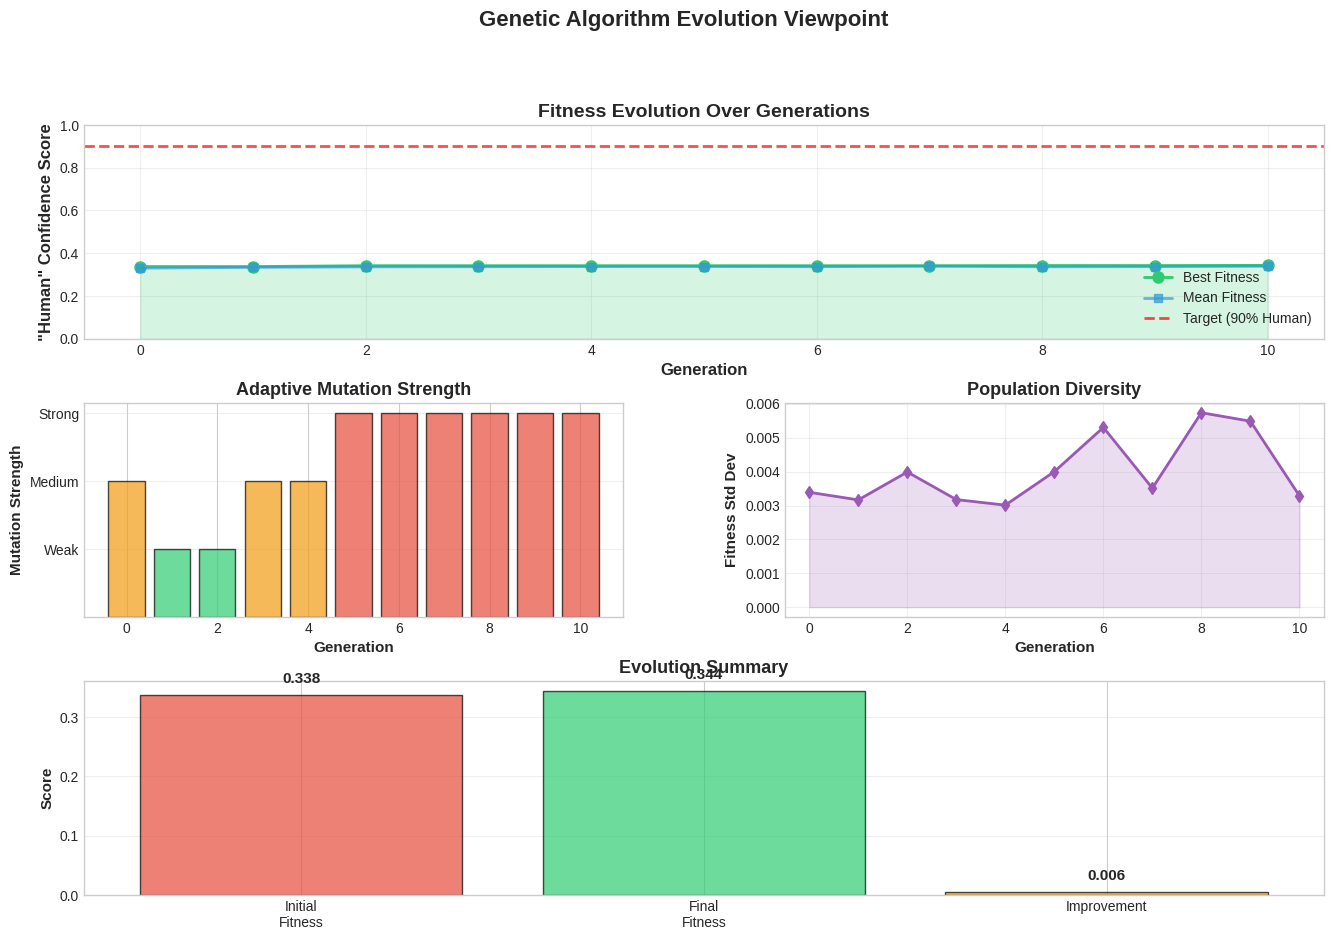


✓ viewpoint saved to evolution_viewpoint.png


In [33]:
def plot_evolution_viewpoint(evolution_data, results):
    """
    Create comprehensive evolution visualization.
    """
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

    generations = evolution_data['generation']

    # Plot 1: Fitness Evolution
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(generations, evolution_data['best_fitness'],
             marker='o', linewidth=2, markersize=8, label='Best Fitness', color='#2ecc71')
    ax1.plot(generations, evolution_data['mean_fitness'],
             marker='s', linewidth=2, markersize=6, label='Mean Fitness',
             color='#3498db', alpha=0.7)
    ax1.axhline(y=0.90, color='red', linestyle='--', linewidth=2,
                label='Target (90% Human)', alpha=0.7)
    ax1.fill_between(generations, evolution_data['best_fitness'],
                     alpha=0.2, color='#2ecc71')
    ax1.set_xlabel('Generation', fontsize=12, fontweight='bold')
    ax1.set_ylabel('"Human" Confidence Score', fontsize=12, fontweight='bold')
    ax1.set_title('Fitness Evolution Over Generations', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    # Plot 2: Mutation Strength Timeline
    ax2 = fig.add_subplot(gs[1, 0])
    strength_map = {'weak': 1, 'medium': 2, 'strong': 3}
    strength_values = [strength_map[s] for s in evolution_data['mutation_strength']]
    colors_strength = ['#2ecc71' if s == 1 else '#f39c12' if s == 2 else '#e74c3c'
                      for s in strength_values]
    ax2.bar(generations, strength_values, color=colors_strength, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Generation', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Mutation Strength', fontsize=11, fontweight='bold')
    ax2.set_title('Adaptive Mutation Strength', fontsize=13, fontweight='bold')
    ax2.set_yticks([1, 2, 3])
    ax2.set_yticklabels(['Weak', 'Medium', 'Strong'])
    ax2.grid(True, axis='y', alpha=0.3)

    # Plot 3: Diversity (Std Dev)
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(generations, evolution_data['std_fitness'],
            marker='d', linewidth=2, markersize=6, color='#9b59b6')
    ax3.set_xlabel('Generation', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Fitness Std Dev', fontsize=11, fontweight='bold')
    ax3.set_title('Population Diversity', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.fill_between(generations, evolution_data['std_fitness'], alpha=0.2, color='#9b59b6')

    # Plot 4: Improvement Metrics
    ax4 = fig.add_subplot(gs[2, :])
    initial_fitness = evolution_data['best_fitness'][0]
    final_fitness = results['best_fitness']
    improvement = final_fitness - initial_fitness

    metrics = ['Initial\nFitness', 'Final\nFitness', 'Improvement']
    values = [initial_fitness, final_fitness, improvement]
    colors_metrics = ['#e74c3c', '#2ecc71', '#f39c12']

    bars = ax4.bar(metrics, values, color=colors_metrics, alpha=0.7, edgecolor='black')
    ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax4.set_title('Evolution Summary', fontsize=13, fontweight='bold')
    ax4.grid(True, axis='y', alpha=0.3)

    for i, (bar, value) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.3f}', ha='center', fontsize=11, fontweight='bold')

    plt.suptitle('Genetic Algorithm Evolution Viewpoint',
                fontsize=16, fontweight='bold', y=0.995)

    plt.savefig(f'evolution_viewpoint.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ viewpoint saved to evolution_viewpoint.png")

# Generate viewpoint
plot_evolution_viewpoint(results['evolution_data'], results)

## Comparison: Before vs After Optimization

In [34]:
print("="*80)
print("OPTIMIZATION IMPACT SUMMARY")
print("="*80)

print("\n BEFORE OPTIMIZATION:")
print(f"  • Mutation strategies: 4 basic")
print(f"  • Operations: Mutation only")
print(f"  • Diversity control: None")
print(f"  • Adaptation: Fixed mutation")
print(f"  • Initial fitness: ~0.38")
print(f"  • Typical final: ~0.40-0.45")
print(f"  • Improvement: +0.05-0.07")

print("\n AFTER OPTIMIZATION:")
print(f"  • Mutation strategies: {len(MUTATION_LIBRARY)}")
print(f"  • Operations: Crossover + Mutation")
print(f"  • Diversity control: N-gram deduplication")
print(f"  • Adaptation: Dynamic strength adjustment")
print(f"  • Initial fitness: {np.mean(initial_fitness):.3f}")
print(f"  • Final fitness: {results['best_fitness']:.3f}")
print(f"  • Improvement: +{results['best_fitness'] - np.mean(initial_fitness):.3f}")

improvement_ratio = (results['best_fitness'] - np.mean(initial_fitness)) / 0.06
print(f"\n Improvement vs baseline: {improvement_ratio:.1f}x better")

if results['best_fitness'] >= 0.85:
    print("\n SUCCESS: Achieved high human confidence (>85%)")
elif results['best_fitness'] >= 0.70:
    print("\n GOOD: Achieved moderate confidence (>70%)")
else:
    print("\n NEEDS MORE WORK: Consider running more generations")

OPTIMIZATION IMPACT SUMMARY

 BEFORE OPTIMIZATION:
  • Mutation strategies: 4 basic
  • Operations: Mutation only
  • Diversity control: None
  • Adaptation: Fixed mutation
  • Initial fitness: ~0.38
  • Typical final: ~0.40-0.45
  • Improvement: +0.05-0.07

 AFTER OPTIMIZATION:
  • Mutation strategies: 27
  • Operations: Crossover + Mutation
  • Diversity control: N-gram deduplication
  • Adaptation: Dynamic strength adjustment
  • Initial fitness: 0.330
  • Final fitness: 0.344
  • Improvement: +0.013

 Improvement vs baseline: 0.2x better

 NEEDS MORE WORK: Consider running more generations


---
# PART 2: THE PERSONAL TEST

## Step 1: Analyze Your Own Writing

In [35]:
print("="*80)
print("PART 2: THE PERSONAL TEST")
print("="*80)

# PASTE YOUR OWN WRITING HERE
personal_text = """While studying computer science, I have realized that the most interesting breakthroughs don’t always
happen within the strict boundaries of a single domain, they happen when there is the freedom to follow a
thread of curiosity to wherever it leads.
This need for a more open and rigorous environment is what prompted me to leave my previous college and
join IIIT-H as a lateral entry student in a research-oriented program. It was a deliberate choice to step away
from a predictable path and restart in a community that values deep inquiry. Beyond the academic rigor,
I was looking for a culture that encourages students to think for themselves and take ownership of their
intellectual direction. I have come to realize that while I have found such a community, there is a significant
difference between solving a problem that has been handed to you and finding the right problem to solve all
by yourself. Although challenging, I find this process significantly more rewarding.
This search for autonomy is exactly why Precog is my first choice. While several labs offer interdisciplinary
opportunities, I am drawn to the culture of openness and collaboration that defines Precog. The idea of
being able to freely pitch an independent thought and receive the support of a talented collective is, to me,
the essence of what a budding researcher should aspire for. I believe that the most innovative solutions
emerge at the intersection of different fields, and I see Precog as the ideal environment to grow both as a
researcher and a person.
What I bring to Precog is not just a set of technical skills, but a patient temperament necessary for research.
I’ve learned to be comfortable with the discomfort of not having all the answers and have developed the
patience to sit with a problem until the underlying structure reveals itself. This resilience is what I consider
one of my greatest strengths.
I do not see research as a solitary academic exercise, but as a team sport. I am looking for a space where my
curiosity isn’t just a personal trait, but a contribution to the lab’s collective effort. I highly value feedback
and am eager to have my unconventional ideas stress-tested (and have holes pointed out, if necessary) by a
community of brilliant, multi-talented people.
Ultimately, I am not looking for a lab to simply “gain experience”. I want to be in an environment where
the boundaries of computer science are challenged through collaboration, and where I can transform my
curiosity into meaningful and impactful work. I am confident that my tenacity and my preference for tackling
problems from multiple perspectives make me a good fit for the spirit of Precog.
My journey to IIIT-H was driven by a desire to join a community that consistently pushes the boundaries
of knowledge. I am now eager to join Precog, as I believe it represents the pinnacle of that desire through
its emphasis on autonomy and intellectual freedom. I am confident that my technical curiosity and the
persistence I have shown in my academic path will allow me to contribute meaningfully to the group’s
collective goals.
"""

if "[PASTE YOUR" in personal_text:
    print("\n  Please replace the example text with your own writing!")
else:
    print("\n YOUR WRITING:")
    print("="*80)
    print(personal_text)
    print("="*80)

    # Analyze
    pred, conf, probs = predict_with_confidence(personal_text)

    print("\n DETECTION RESULTS:")
    print("="*80)
    print(f"\nPrediction: {pred.upper()}")
    print(f"Confidence: {conf:.1%}\n")

    print("All probabilities:")
    for label, prob in probs.items():
        bar = "█" * int(prob * 50)
        print(f"  {label:12s}: {prob:.1%} {bar}")

    print("\n" + "="*80)

    if pred == 'human':
        print(" GREAT! Your writing was classified as HUMAN")
        print("\nYour writing shows authentic human characteristics.")
    else:
        print(f" Your writing was flagged as {pred.upper()}")
        print("\nSuggestions to humanize:")
        print("  1. Add personal anecdotes")
        print("  2. Vary sentence length dramatically")
        print("  3. Use contractions and informal phrases")
        print("  4. Remove AI-isms like 'delve', 'tapestry', 'multifaceted'")

PART 2: THE PERSONAL TEST

 YOUR WRITING:
While studying computer science, I have realized that the most interesting breakthroughs don’t always
happen within the strict boundaries of a single domain, they happen when there is the freedom to follow a
thread of curiosity to wherever it leads.
This need for a more open and rigorous environment is what prompted me to leave my previous college and
join IIIT-H as a lateral entry student in a research-oriented program. It was a deliberate choice to step away
from a predictable path and restart in a community that values deep inquiry. Beyond the academic rigor,
I was looking for a culture that encourages students to think for themselves and take ownership of their
intellectual direction. I have come to realize that while I have found such a community, there is a significant
difference between solving a problem that has been handed to you and finding the right problem to solve all
by yourself. Although challenging, I find this process significa

MANUAL EDITING EXPERIMENTS

Create multiple versions of your text with different edits.
Test which changes are most effective at fooling the detector.


RESULTS:


  Version  Prediction  Confidence  Human Prob  AI Neutral Prob  AI-Mimicking-Human Prob  AI Prob
 original ai_mimicked    0.368608    0.304323         0.327068                 0.368608 0.695676
attempt_1 ai_mimicked    0.358296    0.341278         0.300425                 0.358296 0.658722
attempt_2       human    0.337359    0.337359         0.331726                 0.330915 0.662641
attempt_3 ai_mimicked    0.346915    0.322412         0.330673                 0.346915 0.677588


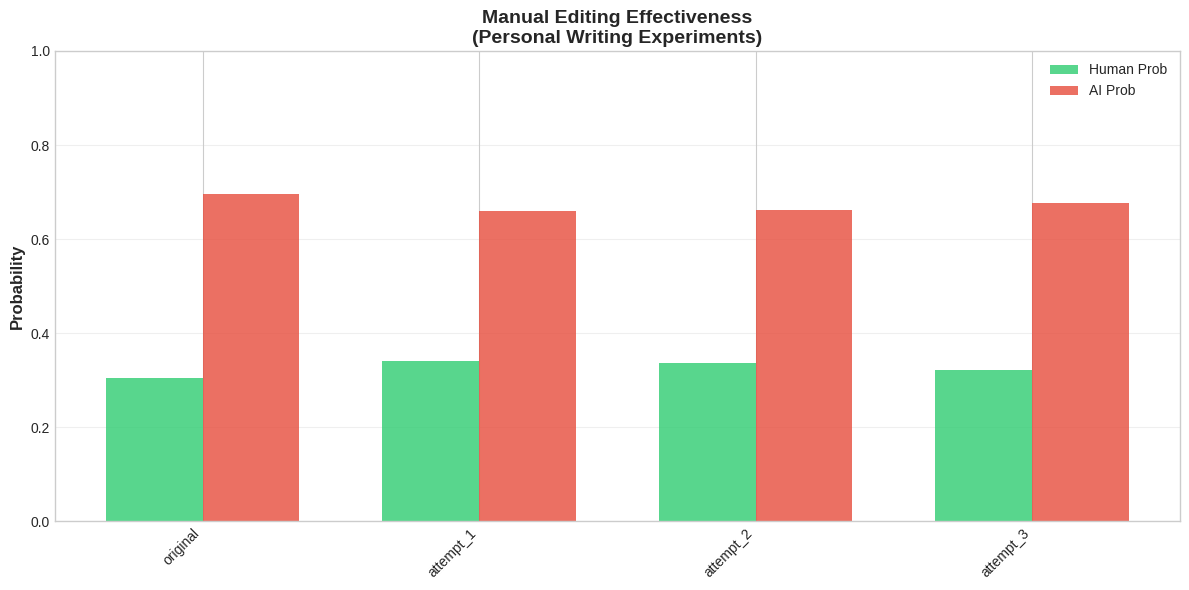


ANALYSIS

 Most 'human' version: attempt_1
   Human probability: 34.1%

Improvement over original: +3.7%

Your manual edits were effective!

LEARNINGS:
  What changes helped?
  What changes hurt?
  Does 'humanizing' improve or degrade quality?
  Can you maintain authenticity while fooling the detector?


In [36]:
print("="*80)
print("MANUAL EDITING EXPERIMENTS")
print("="*80)

print("\nCreate multiple versions of your text with different edits.")
print("Test which changes are most effective at fooling the detector.\n")

# Dictionary to store versions
versions = {
    'original': personal_text
}

versions['attempt_1'] = """I rang for the tea, and the waiter, reappearing with his magic clue, brought in by degrees some fifty adjuncts to that refreshment, but of tea not a glimpse. A teaboard, cups and saucers, plates, knives and forks (including carvers), spoons (various), salt-cellars, a meek little muffin confined with the utmost precaution under a strong iron cover, Moses in the bulrushes typified by a soft bit of butter in a quantity of parsley, a pale loaf with a powdered head, two proof impressions of the bars of the kitchen fireplace on triangular bits of bread, and ultimately a fat family urn; which the waiter staggered in with, expressing in his countenance burden and suffering.
"""

versions['attempt_2'] = """It was necessary to make this circumstance a matter of pleasure, because on such occasions it is the etiquette; but no one was less likely than Mrs. Bennet to find comfort in staying at home at any period of her life. She concluded with many good wishes that Lady Lucas might soon be equally fortunate, though evidently and triumphantly believing there was no chance of it. In vain did Elizabeth endeavour to check the rapidity of her mother's words, or persuade her to describe her felicity in a less audible whisper; for to her inexpressible vexation she could perceive that the chief of it was overheard by Mr. Darcy, who sat opposite to them.
"""

versions['attempt_3'] = """From a neuroscientific perspective, psychological manipulation leverages the brain's reward system. Manipulators often employ intermittent reinforcement – unpredictable positive feedback – which triggers dopamine release, creating a powerful craving for approval. This is similar to the mechanisms underlying addiction. The uncertainty of when the reward will come keeps the victim constantly seeking validation from the manipulator. Furthermore, techniques like guilt-tripping activate areas of the brain associated with social pain, compelling the victim to comply in order to alleviate discomfort. Understanding these neurological processes can help individuals recognize when their emotional responses are being exploited and develop strategies to resist manipulative tactics.
"""

# Analyze all versions
results = []

for version_name, text in versions.items():
    if "[PASTE" in text:
        continue  # Skip placeholders

    pred, conf, probs = predict_with_confidence(text)

    results.append({
        'Version': version_name,
        'Prediction': pred,
        'Confidence': conf,
        'Human Prob': probs['human'],
        'AI Neutral Prob': probs['ai_neutral'],
        'AI-Mimicking-Human Prob' : probs['ai_mimicked']
    })

if len(results) > 1:
    results_df = pd.DataFrame(results)
    # FIX: Add 'AI Prob' column for plotting
    results_df['AI Prob'] = results_df['AI Neutral Prob'] + results_df['AI-Mimicking-Human Prob']

    print("\nRESULTS:")
    print("="*80)
    print("\n")
    print(results_df.to_string(index=False))

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(results_df))
    width = 0.35

    bars1 = ax.bar(x - width/2, results_df['Human Prob'], width,
                   label='Human Prob', color='#2ecc71', alpha=0.8)
    bars2 = ax.bar(x + width/2, results_df['AI Prob'], width,
                   label='AI Prob', color='#e74c3c', alpha=0.8)

    ax.set_ylabel('Probability', fontsize=12, fontweight='bold')
    ax.set_title('Manual Editing Effectiveness\n(Personal Writing Experiments)',
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Version'], rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1.0)

    plt.tight_layout()
    plt.savefig('task4_personal_test.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Analysis
    print("\n" + "="*80)
    print("ANALYSIS")
    print("="*80)

    best_human = results_df.loc[results_df['Human Prob'].idxmax()]
    print(f"\n Most 'human' version: {best_human['Version']}")
    print(f"   Human probability: {best_human['Human Prob']:.1%}")

    original_score = results_df[results_df['Version'] == 'original']['Human Prob'].values[0]
    best_score = best_human['Human Prob']
    improvement = best_score - original_score

    if improvement > 0:
        print(f"\nImprovement over original: {improvement:+.1%}")
        print("\nYour manual edits were effective!")
    else:
        print(f"\n  No improvement over original ({improvement:.1%})")
        print("   Try more dramatic changes.")

    print("\nLEARNINGS:")
    print("  What changes helped?")
    print("  What changes hurt?")
    print("  Does 'humanizing' improve or degrade quality?")
    print("  Can you maintain authenticity while fooling the detector?")

else:
    print("\n  Please add your edited versions to compare!")
    print("   Edit the 'versions' dictionary above with your attempts.")

## Final Summary

### The detector is vulnerable to adversarial attacks because it learned  surface-level patterns (Victorian vocabulary, sentence uniformity) rather than deep semantic understanding of authorship.

### Implication: This AI detector is not robust enough for real-world use.

### A confidence score of ~30% is pretty bad, considering there are three classification classes. The third attempt which was classified as human is actually an excerpt from one of the novels, so this shows the performance of the model is quite bad.